In [46]:
import matplotlib as plt
# --- Global font: Helvetica ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['svg.fonttype'] = 'none'  # keep text editable in SVGs


In [36]:
# --- Napari ROI placement with fixed size + manual Save/Load (no magicgui) ---

%gui qt

import os, json
import numpy as np
import cv2
import napari
from qtpy.QtWidgets import QWidget, QVBoxLayout, QHBoxLayout, QPushButton, QLabel, QFileDialog
from contextlib import contextmanager

# -------- Settings --------
video_path = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\ir_dye_benchmark\ir_dye_60sec_120secDye_180sec_sideA_thanB_2024-02-27-152124-0000_8bit.avi'
roi_frame_index = 1650
expected_n_rois  = 16
FIX_W, FIX_H     = 20, 20   # fixed ROI size (pixels)
default_json     = os.path.join(os.path.dirname(video_path), 'rois_napari.json')
# --------------------------

# Grab frame
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open: {video_path}")
cap.set(cv2.CAP_PROP_POS_FRAMES, int(roi_frame_index))
ok, frame = cap.read()
cap.release()
if not ok:
    raise RuntimeError(f"Could not read frame {roi_frame_index}")

img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if frame.ndim == 3 and frame.shape[2] == 3 else frame.copy()
H, W = img_rgb.shape[:2]

viewer = napari.Viewer()
viewer.add_image(img_rgb, name='ROI frame')

shapes = viewer.add_shapes(
    name='ROIs',
    shape_type='rectangle',
    edge_color='yellow',
    face_color='transparent'
)
shapes.mode = 'add_rectangle'

# -------- Fixed-size enforcement --------
_is_updating = False

@contextmanager
def _update_guard():
    global _is_updating
    _is_updating = True
    try:
        yield
    finally:
        _is_updating = False

def _coerce_rect_size(rect: np.ndarray) -> np.ndarray:
    # rect: (4,2) array in (y,x). Corners may be in any order.
    ys, xs = rect[:, 0], rect[:, 1]
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    cy, cx = (y_min + y_max) / 2.0, (x_min + x_max) / 2.0
    half_h = FIX_H / 2.0
    half_w = FIX_W / 2.0
    y1, y2 = np.clip([cy - half_h, cy + half_h], 0, H-1)
    x1, x2 = np.clip([cx - half_w, cx + half_w], 0, W-1)
    return np.array([[y1, x1],
                     [y1, x2],
                     [y2, x2],
                     [y2, x1]], dtype=float)

def _enforce_all_sizes():
    with _update_guard():
        if len(shapes.data) == 0:
            return
        fixed = [_coerce_rect_size(r.copy()) for r in shapes.data]
        shapes.data = fixed
        status_label.setText(f"ROIs: {len(shapes.data)} / {expected_n_rois}")

def _on_data_change(event=None):
    if _is_updating:
        return
    _enforce_all_sizes()

shapes.events.data.connect(_on_data_change)

# -------- Simple dock: Save / Load / Status --------
dock = QWidget()
vbox = QVBoxLayout(dock)
status_label = QLabel(f"ROIs: 0 / {expected_n_rois}")
vbox.addWidget(status_label)

btn_row = QHBoxLayout()
btn_save = QPushButton("Save ROIs")
btn_load = QPushButton("Load ROIs")
btn_row.addWidget(btn_save)
btn_row.addWidget(btn_load)
vbox.addLayout(btn_row)

viewer.window.add_dock_widget(dock, area='right', name='ROI Tools')

def _save_dialog():
    path, _ = QFileDialog.getSaveFileName(dock, "Save ROIs", default_json, "JSON Files (*.json)")
    if not path:
        return
    rois = []
    for i, data in enumerate(shapes.data):
        ys = data[:, 0]; xs = data[:, 1]
        y1, y2 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
        x1, x2 = int(np.floor(xs.min())), int(np.ceil(xs.max()))
        rois.append({"name": f"ROI_{i+1:02d}", "x1": x1, "y1": y1, "x2": x2, "y2": y2})
    with open(path, 'w') as f:
        json.dump(rois, f, indent=2)
    status_label.setText(f"Saved {len(rois)} ROIs → {os.path.basename(path)}")

def _load_dialog():
    path, _ = QFileDialog.getOpenFileName(dock, "Load ROIs", default_json, "JSON Files (*.json)")
    if not path:
        return
    with open(path, 'r') as f:
        rois = json.load(f)
    rects = []
    for r in rois:
        x1, y1, x2, y2 = r['x1'], r['y1'], r['x2'], r['y2']
        rects.append(np.array([[y1, x1],
                               [y1, x2],
                               [y2, x2],
                               [y2, x1]], dtype=float))
    with _update_guard():
        shapes.data = rects
    _enforce_all_sizes()
    status_label.setText(f"Loaded {len(shapes.data)} ROIs")

btn_save.clicked.connect(_save_dialog)
btn_load.clicked.connect(_load_dialog)

# Helpful overlay text
viewer.text_overlay.visible = True
viewer.text_overlay.position = 'top_left'
viewer.text_overlay.text = (
    f"Draw rectangles (auto-fixed to {FIX_W}×{FIX_H}px).\n"
    "Toolbar: Add Rectangle • Move with mouse • Delete with Del.\n"
    "Use Save/Load in the dock anytime (no need to close the window)."
)


C:\Oded_data\seqFISH_analysis\seqFISH_env_2\Lib\site-packages\napari_tools_menu\__init__.py:165: FutureWarning: Public access to Window.qt_viewer is deprecated and will be removed in
v0.6.0. It is considered an "implementation detail" of the napari
application, not part of the napari viewer model. If your use case
requires access to qt_viewer, please open an issue to discuss.
  self.tools_menu = ToolsMenu(self, self.qt_viewer.viewer)


In [49]:
import os, json
import numpy as np
import pandas as pd
import cv2

# -------- Settings --------
video_path = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\ir_dye_benchmark\ir_dye_60sec_120secDye_180sec_sideA_thanB_2024-02-27-152124-0000_8bit.avi'
rois_json  = os.path.join(os.path.dirname(video_path), 'rois_napari_3.json')

convert_to_gray = True   # intensity from grayscale
baseline_frames = 500    # use first N frames for F0
downsample = 1           # >1 to skip frames

out_csv = os.path.join(os.path.dirname(video_path), 'roi_dff.csv')
# --------------------------

# Load ROIs
with open(rois_json, 'r') as f:
    rois = json.load(f)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS) or 1.0
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

roi_names = [r['name'] for r in rois]
intensity_traces = {name: [] for name in roi_names}
frames_idx = []

# Pass 1: collect raw intensities
fidx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    if fidx % downsample == 0:
        if convert_to_gray and frame.ndim == 3:
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            img = frame
        row_vals = {}
        for r in rois:
            x1, y1, x2, y2 = r['x1'], r['y1'], r['x2'], r['y2']
            patch = img[y1:y2, x1:x2]
            val = float(patch.mean()) if patch.size > 0 else np.nan
            row_vals[r['name']] = val
            intensity_traces[r['name']].append(val)
        frames_idx.append(fidx)
    fidx += 1

cap.release()

# Convert to DataFrame
df = pd.DataFrame(intensity_traces)
df.insert(0, "frame", frames_idx)
df.insert(1, "time_s", np.array(frames_idx) / fps)

# Compute ΔF/F0
dff = df.copy()
for name in roi_names:
    trace = df[name].to_numpy()
    F0 = np.nanmean(trace[:baseline_frames])
    dff[name] = (trace - F0) / F0
    dff[name] = -(trace - F0) / F0

#dff.to_csv(out_csv, index=False)
print(f"Saved ΔF/F0 traces → {out_csv}")
dff.head()


Saved ΔF/F0 traces → U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\ir_dye_benchmark\roi_dff.csv


,frame,time_s,ROI_01,ROI_02,ROI_03,ROI_04
0,0,0.0,0.008430,0.008713,0.005777,0.009111
1,1,0.1,-0.001012,0.000497,-0.002210,0.001478
2,2,0.2,-0.002880,-0.000588,-0.002349,0.001478
3,3,0.3,-0.002457,0.000032,0.000355,0.001063
4,4,0.4,-0.005540,-0.000123,0.000525,0.001063


In [3]:
import os, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# -------- Settings --------
video_path = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\ir_dye_benchmark\ir_dye_60sec_120secDye_180sec_sideA_thanB_2024-02-27-152124-0000_8bit.avi'
rois_json  = os.path.join(os.path.dirname(video_path), 'rois_napari_3.json')

convert_to_gray = True
downsample = 2            # set 1 for every frame
start_frame = 0
end_frame   = None        # None = until end
# --------------------------

with open(rois_json, 'r') as f:
    rois = json.load(f)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS) or 1.0
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if end_frame is None:
    end_frame = n_frames - 1
end_frame = min(end_frame, n_frames - 1)

# Prepare output rows
rows = []

cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))
fidx = start_frame

while fidx <= end_frame:
    ok, frame = cap.read()
    if not ok:
        break

    if (fidx - start_frame) % downsample == 0:
        if convert_to_gray and frame.ndim == 3:
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            img = frame

        t = fidx / fps

        for r in rois:
            name = r["name"]
            x1, y1, x2, y2 = r["x1"], r["y1"], r["x2"], r["y2"]
            patch = img[y1:y2, x1:x2]

            if patch.size == 0:
                rows.append({
                    "frame": fidx, "time_s": t, "roi": name,
                    "v_min": np.nan, "v_max": np.nan, "v_delta": np.nan,
                    "h_min": np.nan, "h_max": np.nan, "h_delta": np.nan,
                })
                continue

            # Vertical profile: one value per y-row (mean across x)
            v_prof = patch.mean(axis=1)  # shape (H,)
            v_min = float(np.nanmin(v_prof))
            v_max = float(np.nanmax(v_prof))
            v_delta = v_max - v_min

            # Horizontal profile: one value per x-column (mean across y)
            h_prof = patch.mean(axis=0)  # shape (W,)
            h_min = float(np.nanmin(h_prof))
            h_max = float(np.nanmax(h_prof))
            h_delta = h_max - h_min

            rows.append({
                "frame": fidx, "time_s": t, "roi": name,
                "v_min": v_min, "v_max": v_max, "v_delta": v_delta,
                "h_min": h_min, "h_max": h_max, "h_delta": h_delta,
            })

    fidx += 1

cap.release()

metrics = pd.DataFrame(rows)
metrics.head()

,frame,time_s,roi,v_min,v_max,v_delta,h_min,h_max,h_delta
0,0,0.0,ROI_01,124.761905,129.333333,4.571429,122.857143,130.380952,7.523810
1,0,0.0,ROI_02,116.000000,116.000000,0.000000,116.000000,116.000000,0.000000
2,0,0.0,ROI_03,142.190476,146.761905,4.571429,135.904762,154.333333,18.428571
3,0,0.0,ROI_04,129.285714,130.000000,0.714286,129.761905,130.000000,0.238095
4,2,0.2,ROI_01,124.952381,130.714286,5.761905,123.952381,132.571429,8.619048


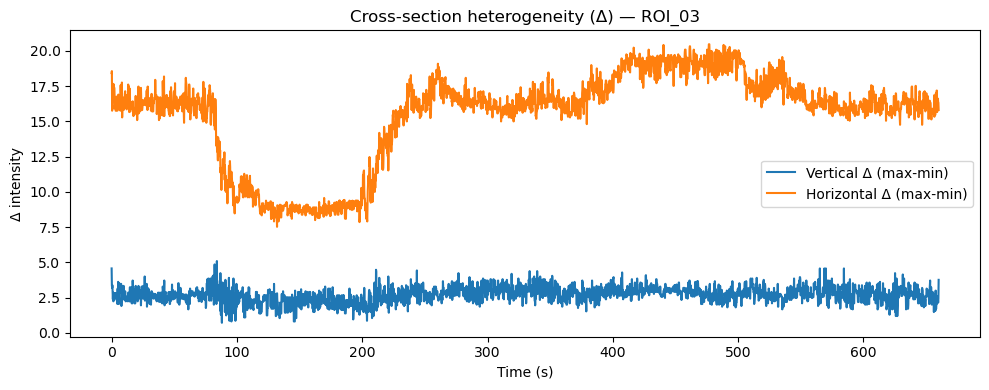

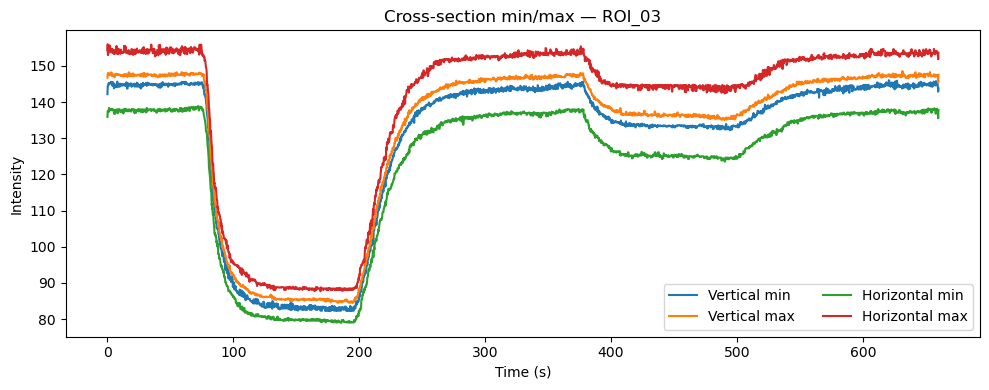


=== MAX VERTICAL DELTA ===
ROI:          ROI_01
Frame:        3810
Time (s):     381.000
Vertical Δ:   7.761905
Vertical min: 111.904762
Vertical max: 119.666667
Horizontal Δ (same frame/ROI): 7.380952


In [6]:
roi_name = "ROI_03"  # change

m = metrics[metrics["roi"] == roi_name].sort_values("time_s")

plt.figure(figsize=(10,4))
plt.plot(m["time_s"], m["v_delta"], label="Vertical Δ (max-min)")
plt.plot(m["time_s"], m["h_delta"], label="Horizontal Δ (max-min)")
plt.xlabel("Time (s)")
plt.ylabel("Δ intensity")
plt.title(f"Cross-section heterogeneity (Δ) — {roi_name}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(m["time_s"], m["v_min"], label="Vertical min")
plt.plot(m["time_s"], m["v_max"], label="Vertical max")
plt.plot(m["time_s"], m["h_min"], label="Horizontal min")
plt.plot(m["time_s"], m["h_max"], label="Horizontal max")
plt.xlabel("Time (s)")
plt.ylabel("Intensity")
plt.title(f"Cross-section min/max — {roi_name}")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
# Drop NaNs just in case
m_clean = metrics.dropna(subset=["v_delta"])

if len(m_clean) == 0:
    print("No valid vertical delta values found.")
else:
    idx = m_clean["v_delta"].idxmax()
    row = m_clean.loc[idx]

    print("\n=== MAX VERTICAL DELTA ===")
    print(f"ROI:          {row['roi']}")
    print(f"Frame:        {int(row['frame'])}")
    print(f"Time (s):     {row['time_s']:.3f}")
    print(f"Vertical Δ:   {row['v_delta']:.6f}")
    print(f"Vertical min: {row['v_min']:.6f}")
    print(f"Vertical max: {row['v_max']:.6f}")
    print(f"Horizontal Δ (same frame/ROI): {row['h_delta']:.6f}")

C:\Users\maysel0000\AppData\Local\Temp\ipykernel_44704\3356499031.py:11: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()


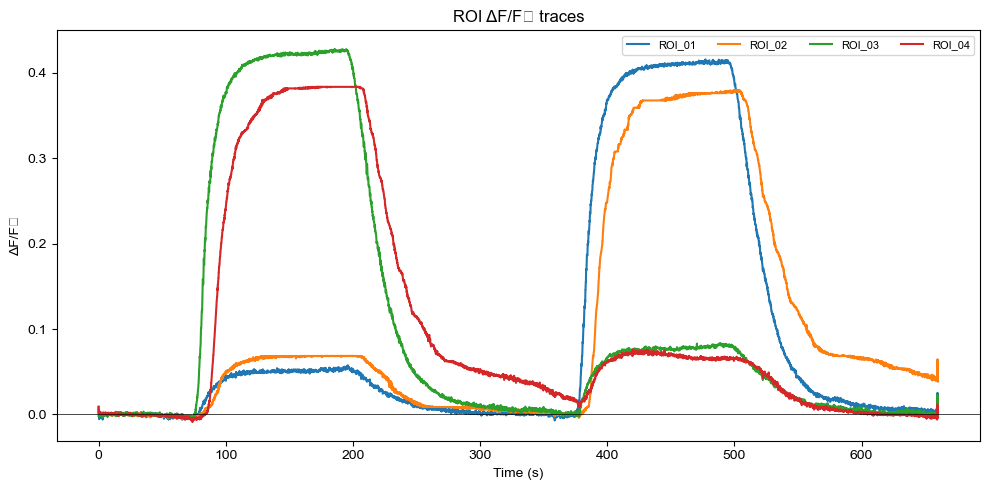

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for name in roi_names:
    plt.plot(dff['time_s'], dff[name], label=name)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel('ΔF/F₀')
plt.title('ROI ΔF/F₀ traces')
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


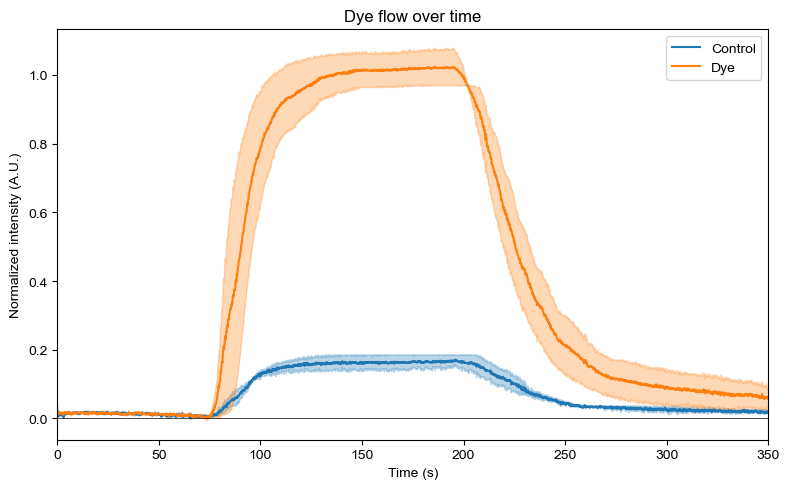

In [59]:
import matplotlib.pyplot as plt

# ROI groups
group1 = [f"ROI_{i:02d}" for i in range(1, 3)]   # 1–8
group2 = [f"ROI_{i:02d}" for i in range(3, 5)]  # 9–16

# Compute mean ± SEM
g1_mean = dff[group1].mean(axis=1)
g1_sem  = dff[group1].sem(axis=1)
g2_mean = dff[group2].mean(axis=1)
g2_sem  = dff[group2].sem(axis=1)

# --- Normalize: group1 to [0,1], group2 scaled to same min/max ---
g1_min, g1_max = g1_mean.min(), g1_mean.max()
g1_norm = (g1_mean - g1_min) / (g1_max - g1_min)
g1_sem_norm = g1_sem / (g1_max - g1_min)

g2_norm = (g2_mean - g1_min) / (g1_max - g1_min)
g2_sem_norm = g2_sem / (g1_max - g1_min)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(dff['time_s'], g1_norm, color='tab:blue', label='Control')
plt.fill_between(dff['time_s'], g1_norm - g1_sem_norm, g1_norm + g1_sem_norm,
                 color='tab:blue', alpha=0.3)

plt.plot(dff['time_s'], g2_norm, color='tab:orange', label='Dye')
plt.fill_between(dff['time_s'], g2_norm - g2_sem_norm, g2_norm + g2_sem_norm,
                 color='tab:orange', alpha=0.3)

plt.axhline(0, color='k', lw=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Normalized intensity (A.U.)")
plt.xlim([0,350])
plt.title("Dye flow over time")
plt.legend()
plt.tight_layout()
plot_dir = 'U:\\Scientific Data\\RG-AS04-Data01\\Oded_Mayseless\\innate_behavior\\figures\\20241115_behavior'
save_path_svg = os.path.join(plot_dir, 'normalizd_dye_flow_2_sides.svg')
plt.savefig(save_path_svg, format='svg')
plt.show()


fps = 10.000
ROI_03 cross @ 841.10 frames, ROI_04 cross @ 956.52 frames
Δt = 115.42 frames = 11.542 s
Distance = 477.0 px = 40.886 mm
Speed = 3.542 mm/s


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_44704\1981725938.py:101: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()


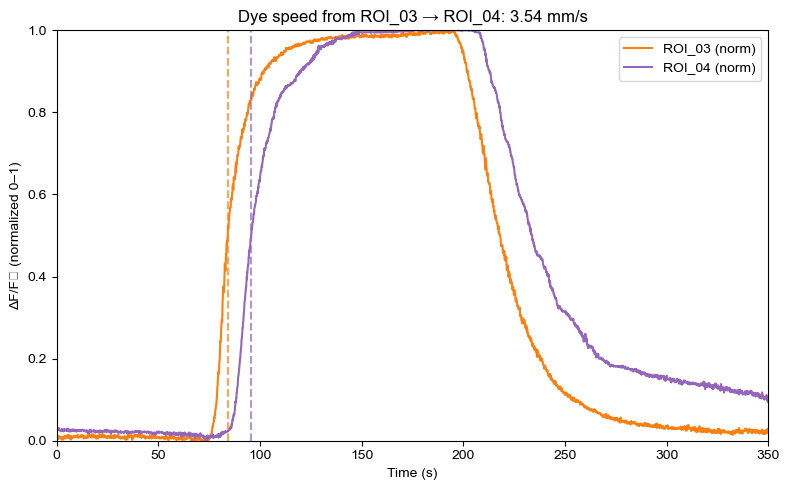

In [58]:
import numpy as np
import json, os
import matplotlib.pyplot as plt

# --- SETTINGS ---
roi_a = "ROI_03"   # upstream / earlier
roi_b = "ROI_04"   # downstream / later
threshold = 0.5
flow_axis = "x"    # 'x' for left→right flow, 'y' for top→bottom
pixel_to_mm = 30.0 / 350.0  # <-- UPDATE to your calibration!
xlim_seconds = (0, 350)

# --- helpers ---
def minmax01(x):
    x = np.asarray(x, float)
    mn, mx = np.nanmin(x), np.nanmax(x)
    return (x - mn) / (mx - mn + 1e-12)

def first_threshold_crossing_time(y, thr=0.5):
    y = np.asarray(y, float)
    above = y >= thr
    if not np.any(above):
        return np.nan
    idx = np.argmax(above)             # first index where True
    if idx == 0:
        return 0.0
    y0, y1 = y[idx-1], y[idx]          # sub-frame interpolation
    if y1 == y0:
        return float(idx)
    frac = (thr - y0) / (y1 - y0)
    return (idx - 1) + np.clip(frac, 0.0, 1.0)

# --- pull the two traces from your dff DataFrame ---
if roi_a not in dff.columns or roi_b not in dff.columns:
    raise KeyError(f"Expected columns {roi_a} and {roi_b} in dff. Found: {dff.columns.tolist()}")

yA = dff[roi_a].to_numpy()
yB = dff[roi_b].to_numpy()
t  = dff["time_s"].to_numpy()

# normalize each trace to 0–1 (so 0.5 threshold is meaningful)
yA_n = minmax01(yA)
yB_n = minmax01(yB)

# crossing times in frames (sub-frame), then seconds
fps = (1.0 / np.diff(t).mean()) if len(t) > 1 else 10.0
tA_frames = first_threshold_crossing_time(yA_n, threshold)
tB_frames = first_threshold_crossing_time(yB_n, threshold)
dt_frames = tB_frames - tA_frames
dt_sec    = dt_frames / fps

# --- distance between ROI centers from the same JSON you used ---
# -------- Settings --------
video_path = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\ir_dye_benchmark\ir_dye_60sec_120secDye_180sec_sideA_thanB_2024-02-27-152124-0000_8bit.avi'
rois_json  = os.path.join(os.path.dirname(video_path), 'rois_napari_3.json')

with open(rois_json, 'r') as f:
    rois_for_dist = json.load(f)

def center_from_json(name):
    # find ROI entry by 'name'
    entry = next((r for r in rois_for_dist if r["name"] == name), None)
    if entry is None:
        raise KeyError(f"ROI named {name} not found in {rois_json}")
    x1, y1, x2, y2 = entry["x1"], entry["y1"], entry["x2"], entry["y2"]
    return (0.5*(x1+x2), 0.5*(y1+y2))

cxA, cyA = center_from_json(roi_a)
cxB, cyB = center_from_json(roi_b)

if flow_axis.lower() == "x":
    dist_px = abs(cxB - cxA)
elif flow_axis.lower() == "y":
    dist_px = abs(cyB - cyA)
else:
    raise ValueError("flow_axis must be 'x' or 'y'.")

dist_mm = dist_px * pixel_to_mm
speed_mm_s = dist_mm / dt_sec if dt_sec > 0 else np.nan

print(f"fps = {fps:.3f}")
print(f"{roi_a} cross @ {tA_frames:.2f} frames, {roi_b} cross @ {tB_frames:.2f} frames")
print(f"Δt = {dt_frames:.2f} frames = {dt_sec:.3f} s")
print(f"Distance = {dist_px:.1f} px = {dist_mm:.3f} mm")
print(f"Speed = {speed_mm_s:.3f} mm/s")

# --- plot ---
plt.figure(figsize=(8,5))
plt.plot(t, yA_n, label=f"{roi_a} (norm)", color="tab:orange")
plt.plot(t, yB_n, label=f"{roi_b} (norm)", color="tab:purple")
if np.isfinite(tA_frames):
    plt.axvline(tA_frames/fps, color="tab:orange", ls="--", alpha=0.7)
if np.isfinite(tB_frames):
    plt.axvline(tB_frames/fps, color="tab:purple", ls="--", alpha=0.7)
plt.xlim(xlim_seconds)
plt.ylim(0,1)
plt.xlabel("Time (s)")
plt.ylabel("ΔF/F₀ (normalized 0–1)")
plt.title(f"Dye speed from {roi_a} → {roi_b}: {speed_mm_s:.2f} mm/s")
plt.legend()
plt.tight_layout()
plt.show()
